In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
%matplotlib inline

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as scisig
from tqdm import tqdm

import qubex as qx


In [ ]:



ex = qx.Experiment(
    chip_id="64Q",
    muxes=[10],
    qubits=[40, 41, 42, 43],
    # exclude_qubits=[11],
    config_dir="/home/user/test_mukai/qubex_dev/qubex/docs/examples/config",
    params_dir="/home/user/test_mukai/qubex_dev/qubex/docs/examples/config",
)

date: 2025-04-15 14:28:00
python: 3.9.18
qubex: 1.3.3+f52a68a
env: /home/user/test_mukai/qubex_dev
config: /home/user/test_mukai/qubex_dev/qubex/docs/examples/config
params: /home/user/test_mukai/qubex_dev/qubex/docs/examples/config
chip: 64Q (FY2023 64Q 3rd #3 (0,1))
qubits: ['Q40', 'Q41', 'Q42', 'Q43']
muxes: ['MUX10']
boxes: ['qube104']
qube104 : Linked up


In [ ]:
# Configure the measurement devices if necessary
# ex.configure()

In [4]:
# Check the readout waveform
ex.check_waveform()

MeasureResult(mode=<MeasureMode.AVG: 'avg'>, data={'Q40': MeasureData(target='Q40', mode=<MeasureMode.AVG: 'avg'>, raw=array([ 7.8755271e-05-6.22517837e-05j, -2.6742823e-04-4.73214488e-04j,
       -6.0552865e-04+1.34751701e-03j, -3.8717245e-04+7.87866244e-04j,
       -1.8321960e-03+1.04377430e-03j, -7.5077644e-04+9.24716413e-04j,
        8.3402163e-05+1.07135776e-04j, -4.5459808e-04+3.41941603e-04j,
        6.3547950e-06+3.61204788e-04j, -5.4139609e-04+1.14615681e-03j,
       -1.2065163e-03+3.67061439e-04j, -9.1934775e-04-3.93895520e-04j,
        4.9859664e-05-1.10871647e-03j,  4.5095081e-04-5.97254490e-04j,
        4.7145563e-04-7.75572727e-04j,  1.4397188e-03-3.04054411e-04j,
        2.4096286e-03+7.87641678e-04j,  1.3927836e-03+8.66203976e-04j,
        1.2631642e-04+1.36446476e-03j,  8.8691246e-04+1.08132826e-03j,
       -9.0797337e-05+7.42656877e-04j, -1.1383833e-03-3.34297045e-04j,
        7.6979477e-06+6.82918399e-05j,  1.6335894e-04-3.46258254e-04j,
       -1.5132773e-03-8.60430

In [5]:
# Measure the readout SNR
ex.measure_readout_snr()

{'signal': {'Q40': 0.0063043283,
  'Q41': 0.002406332,
  'Q42': 0.0035856552,
  'Q43': 0.0059629423},
 'noise': {'Q40': 0.0068105017,
  'Q41': 0.003716564,
  'Q42': 0.004688141,
  'Q43': 0.0062712426},
 'snr': {'Q40': 0.92567754,
  'Q41': 0.6474615,
  'Q42': 0.7648352,
  'Q43': 0.95083904}}

In [6]:
# Sweep the readout amplitude to find the optimal readout power
ex.sweep_readout_amplitude()

100%|██████████| 21/21 [00:30<00:00,  1.46s/it]


Image saved to ./images/20250415_readout_snr_Q40_1.png


Image saved to ./images/20250415_readout_snr_Q41_1.png


Image saved to ./images/20250415_readout_snr_Q42_1.png


Image saved to ./images/20250415_readout_snr_Q43_1.png


{'signal': {'Q40': array([0.00014965, 0.0009149 , 0.00225106, 0.00304686, 0.00408523,
         0.00536979, 0.00573171, 0.00718054, 0.00789075, 0.00909833,
         0.00993943, 0.01054429, 0.0119231 , 0.01307436, 0.01377559,
         0.01473873, 0.01621024, 0.01695391, 0.01773571, 0.01867313,
         0.0196738 ], dtype=float32),
  'Q41': array([5.8145913e-05, 5.6214444e-04, 1.0209950e-03, 1.2148124e-03,
         1.5778481e-03, 2.1566306e-03, 2.4121546e-03, 2.7939184e-03,
         3.4742684e-03, 3.7530647e-03, 4.0148315e-03, 4.4387756e-03,
         4.7948300e-03, 5.1739793e-03, 5.3525297e-03, 5.9128194e-03,
         6.2772129e-03, 6.6878931e-03, 7.0462641e-03, 7.4079046e-03,
         7.8159822e-03], dtype=float32),
  'Q42': array([0.00012149, 0.00083277, 0.0011506 , 0.00186298, 0.00220418,
         0.00291646, 0.00362763, 0.00397982, 0.00472918, 0.00532882,
         0.00577903, 0.00648552, 0.00717914, 0.00784589, 0.00830145,
         0.00898005, 0.00970704, 0.01021649, 0.01090136, 0.011

In [7]:
# Measure the phase shift caused by the transmission line
phase_shift = ex.measure_phase_shift(
    ex.qubit_labels[0],
    frequency_range=np.arange(10.2, 10.3, 0.002),
)

In [9]:
# Sweep the readout frequency to find resonator frequency
result = ex.scan_resonator_frequencies(
    ex.qubit_labels[0],
    frequency_range=np.arange(10.1, 10.7, 0.002),
    phase_shift=phase_shift,
    save_image=True,
)

Image saved to ./images/20250415_resonator_frequency_scan_MUX10_phase_2.png
Image saved to ./images/20250415_resonator_frequency_scan_MUX10_phase_diff_2.png


In [11]:
def smoothen(data: np.ndarray, t = 1, numtaps: int = 11, smoothing_width: float = 10):
    """Smoothen the data by applying fir filter with zero phase.
    Args:
        data (np.ndarray): data to be smoothened
        t (float): sampling time or interval of sampling
        numtaps (int): number of taps used for fir filter
        smoothing_width (float): time width of smoothing, cutoff = 1/smoothing_width
        
    Returns:
        np.ndarray: smoothened data
    """
    if isinstance(t, np.ndarray):
        dt = t[1] - t[0]
    elif isinstance(t, (float, int)):
        dt = t
    else:
        raise ValueError('t should be either np.ndarray or float')
    
    fs = 1/dt
    cutoff = 1/smoothing_width
    b = scisig.firwin(numtaps=numtaps, cutoff=cutoff, fs=fs)
    data_lp = scisig.filtfilt(b, 1, data) # apply zero phase filter
    return data_lp

def middle_points(x: np.ndarray):
    """Return the middle points of array
    
    Return the middle point of adjacent coordinate (x_i + x_{i+1})/2 as an array
    
    Args:
        x (np.ndarray): array of coordinate
    
    Return:
        np.ndarray: array of middle point
    """
    return 0.5*(x[1:]+x[:-1])
freq_m = middle_points(result['frequency_range'])

In [13]:
res_peak_ids, _ = scisig.find_peaks(-result['phases_diff'], height=0.2 ,distance=50)
freq_res = freq_m[res_peak_ids]
freq_res

array([10.253, 10.369, 10.483, 10.601])

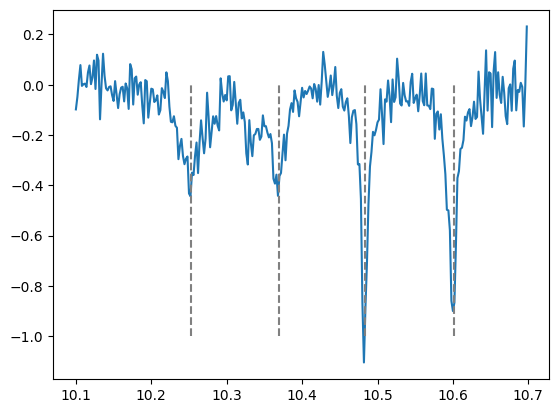

In [17]:
fig, ax = plt.subplots()
ax.plot(result['frequency_range'], result['phases_diff'])
ax.vlines(freq_res, ymin=-1.0, ymax=0, ls="--", color="gray")
# ax.set_ylim(-0.2, 1)

In [ ]:
# Sweep the readout frequency and power
result = ex.resonator_spectroscopy(
    ex.qubit_labels[0],
    frequency_range=np.arange(9.75, 10.75, 0.002),
    power_range=np.arange(-60, 5, 5),
    phase_shift=phase_shift,
)

In [19]:
resonator_frequencies = {
    ex.qubit_labels[0]: freq_res[0],
    ex.qubit_labels[1]: freq_res[1],
    ex.qubit_labels[2]: freq_res[2],
    ex.qubit_labels[3]: freq_res[3],
}

span = 0.050
# Measure the reflection coefficient and fit
for label, freq in resonator_frequencies.items():
    ex.measure_reflection_coefficient(
        label,
        frequency_range=np.arange(freq - 0.5 * span, freq + 0.5 * span, 0.001),
        phase_shift=phase_shift,
    )

Q40
--------------------
Resonance frequency:
  10.252512 GHz
External loss rate:
  15.116428 MHz
Internal loss rate:
  0.000000 MHz
--------------------

Image saved to ./images/20250415_reflection_coefficient_Q40_2.png


Q41
--------------------
Resonance frequency:
  10.367385 GHz
External loss rate:
  17.216808 MHz
Internal loss rate:
  0.000000 MHz
--------------------

Image saved to ./images/20250415_reflection_coefficient_Q41_2.png


Q42
--------------------
Resonance frequency:
  10.482733 GHz
External loss rate:
  4.015155 MHz
Internal loss rate:
  0.000000 MHz
--------------------

Image saved to ./images/20250415_reflection_coefficient_Q42_2.png


Q43
--------------------
Resonance frequency:
  10.599493 GHz
External loss rate:
  3.968278 MHz
Internal loss rate:
  0.000000 MHz
--------------------

Image saved to ./images/20250415_reflection_coefficient_Q43_2.png


In [20]:
# # Sweep the control frequency to find qubit frequency
# result = ex.scan_qubit_frequencies(
#     ex.qubit_labels[0],
#     frequency_range=np.arange(6.5, 9.5, 0.002),
#     control_amplitude=0.1,
#     readout_amplitude=0.01,
# )
power = -45
power_linear = 10 ** (power / 10)
amplitude = np.sqrt(power_linear)

frequency_range=np.arange(7.8, 9.0, 0.005)
freq_q = []

for qubit in tqdm(ex.qubit_labels):
    result = ex.scan_qubit_frequencies(
        qubit,
        frequency_range=frequency_range,
        control_amplitude=amplitude,
        readout_amplitude=0.01,
    )
    
    offset = np.mean(result[1])
    sigma4 = 4 * np.std(result[1])
    fq_peak_ids, _ = scisig.find_peaks(abs(result[1] - offset), height=sigma4)
    if fq_peak_ids.size == 0:
        offset = np.mean(result[2])
        sigma4 = 4 * np.std(result[2])
        fq_peak_ids, _ = scisig.find_peaks(abs(result[2] - offset), height=sigma4)
    freq_q.append(float(result[0][fq_peak_ids[0]]))

    print(freq_q[-1])

  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:21<01:05, 21.84s/it]

8.179999999999993


 50%|█████     | 2/4 [00:43<00:43, 21.88s/it]

8.914999999999976


 75%|███████▌  | 3/4 [01:05<00:21, 21.94s/it]

8.809999999999977


100%|██████████| 4/4 [01:27<00:00, 21.91s/it]

8.089999999999993


In [ ]:
# Sweep control frequency and power
for qubit in ex.qubit_labels:
    result = ex.qubit_spectroscopy(
        qubit,
        frequency_range=np.arange(8.0, 9.0, 0.003),
        power_range=np.arange(-60, 5, 5),
    )

In [21]:
qubit_frequencies = {
    ex.qubit_labels[0]: freq_q[0],
    ex.qubit_labels[1]: freq_q[1],
    ex.qubit_labels[2]: freq_q[2],
    ex.qubit_labels[3]: freq_q[3],
}

span = 0.2 # GHz
# Estimate the control amplitude
for label, freq in qubit_frequencies.items():
    ex.estimate_control_amplitude(
        label,
        frequency_range=np.linspace(freq - 0.7 * span, freq + 0.3 * span, 100),
    )

Target: Q40
Fit : A / √[1 + {(f - f0) / Ω}^2] + C
  A = -0.402 ± 0.03
  f0 = 8.18 ± 0.0004
  Ω = 0.00301 ± 0.0004
  C = 3.34 ± 0.005

Control amplitude estimation : Q40
  0.010000 -> 3.011 MHz
  0.041517 -> 12.500 MHz


Target: Q41
Fit : A / √[1 + {(f - f0) / Ω}^2] + C
  A = -0.0736 ± 0.03
  f0 = 8.85 ± 0.01
  Ω = 0.0144 ± 0.02
  C = 2.66 ± 0.02

Control amplitude estimation : Q41
  0.010000 -> 14.370 MHz
  0.008699 -> 12.500 MHz


Target: Q42
Fit : A / √[1 + {(f - f0) / Ω}^2] + C
  A = -0.215 ± 0.03
  f0 = 8.82 ± 0.001
  Ω = 0.0071 ± 0.002
  C = 4.85 ± 0.009

Control amplitude estimation : Q42
  0.010000 -> 7.097 MHz
  0.017614 -> 12.500 MHz


Target: Q43
Fit : A / √[1 + {(f - f0) / Ω}^2] + C
  A = -0.443 ± 0.03
  f0 = 8.09 ± 0.0004
  Ω = 0.0044 ± 0.0005
  C = 2.01 ± 0.006

Control amplitude estimation : Q43
  0.010000 -> 4.404 MHz
  0.028381 -> 12.500 MHz


In [22]:
# Measure the Rabi oscillation
ex.obtain_rabi_params()

Output()

Target: Q40
Rabi frequency: 14.4 ± 0.02 MHz
'rabi_params' added: {'Q40': {'target': 'Q40', 'frequency': 0.014376574451306476, 'amplitude': 0.003100708814592625, 'phase': -0.022841275824796312, 'offset': 0.00010987292449966823, 'noise': 0.00010624618153087795, 'angle': 2.7660491029408316, 'r2': 0.9974668646601362, 'timestamp': '2025-04-15 16:13:47'}}


Output()

Target: Q41
Rabi frequency: 11.1 ± 0.02 MHz
'rabi_params' updated: {'Q41': {'target': 'Q41', 'frequency': 0.011114797671502195, 'amplitude': 0.0024176135679580403, 'phase': 0.004787209382283353, 'offset': 7.42737809117834e-05, 'noise': 6.447551277233288e-05, 'angle': 0.7007588307049613, 'r2': 0.9986574561497541, 'timestamp': '2025-04-15 16:14:07'}}


Output()

Target: Q42
Rabi frequency: 15.3 ± 0.01 MHz
'rabi_params' updated: {'Q42': {'target': 'Q42', 'frequency': 0.01531347064669499, 'amplitude': 0.003286320612378447, 'phase': 0.009651284520214376, 'offset': 0.00014899149725817443, 'noise': 6.520216993521899e-05, 'angle': 3.360230998196874, 'r2': 0.9990169187370099, 'timestamp': '2025-04-15 16:14:27'}}


Output()

Target: Q43
Rabi frequency: 14.1 ± 0.03 MHz
'rabi_params' updated: {'Q43': {'target': 'Q43', 'frequency': 0.014064843596697822, 'amplitude': 0.002676581175111949, 'phase': 0.05943431715874156, 'offset': 0.0021578257498156314, 'noise': 7.837086741346866e-05, 'angle': 1.0043410221722464, 'r2': 0.9929090321420884, 'timestamp': '2025-04-15 16:14:47'}}


ExperimentResult(data={'Q40': RabiData(target='Q40', data=array([-0.00608352-1.1895901e-03j, -0.00578833-9.5359620e-04j,
       -0.00565824-3.2082218e-04j, -0.00523952+4.0658255e-04j,
       -0.00492917+1.2524260e-03j, -0.00468947+2.6712702e-03j,
       -0.00421769+3.3055227e-03j, -0.00389429+4.0481230e-03j,
       -0.00361293+4.3762326e-03j, -0.00380562+4.6770666e-03j,
       -0.00348305+4.3843389e-03j, -0.00416069+3.8248219e-03j,
       -0.0044917 +2.9613846e-03j, -0.00476142+1.9364017e-03j,
       -0.00520875+8.5422012e-04j, -0.00561372-1.0359977e-04j,
       -0.00582992-6.2046846e-04j, -0.00579439-1.1629066e-03j,
       -0.00595685-8.5013441e-04j, -0.00584384-5.8473949e-04j,
       -0.00563184-7.3450654e-05j, -0.00516517+8.2937424e-04j,
       -0.00486159+1.9587621e-03j, -0.00451492+2.9383537e-03j,
       -0.00408915+3.7545427e-03j, -0.00389887+4.4903401e-03j,
       -0.00372367+4.7945995e-03j, -0.0036996 +4.3328013e-03j,
       -0.00400343+3.9470983e-03j, -0.00418488+3.2500499e-03

In [23]:
# Calculate the control amplitudes
ex.calc_control_amplitudes()

Control amplitude for rabi rate 12.500 MHz

Q40: 0.026084
Q41: 0.033739
Q42: 0.024488
Q43: 0.026662


{'Q40': 0.02608409960732487,
 'Q41': 0.0337388057869449,
 'Q42': 0.024488243628881995,
 'Q43': 0.026662223253449004}

In [24]:
# Reload the configuration files
ex.reload()

In [25]:
# Obtain the Chevron pattern
ex.chevron_pattern(
    ex.qubit_labels,
    detuning_range=np.linspace(-0.05, 0.05, 51),
    time_range=np.arange(0, 201, 4),
)

Obtaining Rabi parameters...
Targets : ['Q40', 'Q41', 'Q42', 'Q43']
Subgroup (1/2) : ['Q40', 'Q43']


100%|██████████| 51/51 [09:45<00:00, 11.48s/it]


Image saved to ./images/20250415_chevron_pattern_Q40_1.png


Resonance frequency
  Q40: 8.181903


Image saved to ./images/20250415_chevron_pattern_Q43_1.png


...

Image saved to ./images/20250415_chevron_pattern_Q41_1.png


Resonance frequency
  Q41: 8.925617


Image saved to ./images/20250415_chevron_pattern_Q42_1.png


Resonance frequency
  Q42: 8.825278


{'time_range': array([  0.,   4.,   8.,  12.,  16.,  20.,  24.,  28.,  32.,  36.,  40.,
         44.,  48.,  52.,  56.,  60.,  64.,  68.,  72.,  76.,  80.,  84.,
         88.,  92.,  96., 100., 104., 108., 112., 116., 120., 124., 128.,
        132., 136., 140., 144., 148., 152., 156., 160., 164., 168., 172.,
        176., 180., 184., 188., 192., 196., 200.]),
 'detuning_range': array([-0.05 , -0.048, -0.046, -0.044, -0.042, -0.04 , -0.038, -0.036,
        -0.034, -0.032, -0.03 , -0.028, -0.026, -0.024, -0.022, -0.02 ,
        -0.018, -0.016, -0.014, -0.012, -0.01 , -0.008, -0.006, -0.004,
        -0.002,  0.   ,  0.002,  0.004,  0.006,  0.008,  0.01 ,  0.012,
         0.014,  0.016,  0.018,  0.02 ,  0.022,  0.024,  0.026,  0.028,
         0.03 ,  0.032,  0.034,  0.036,  0.038,  0.04 ,  0.042,  0.044,
         0.046,  0.048,  0.05 ]),
 'frequencies': {'Q40': 8.181663,
  'Q41': 8.926052,
  'Q42': 8.825165,
  'Q43': 8.087435},
 'chevron_data': {'Q40': array([[0.9441031 , 1.0093696 , 0.906